In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import george

In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)

yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

In [3]:
def exponential_model(x, q, a, m):
    # Rescale time to avoid overflow in exp for calendar-year inputs.
    t = (x - 1950.0) / 50.0
    #exponent = np.clip(m * t, -50.0, 50.0)
    return q + a * np.exp(m * t)


def exponential_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    return params


def log_exponential_likelihood(params):
    q, a, m = params
    model = exponential_model(date, q, a, m)

    if not np.all(np.isfinite(model)):
        return -1e300

    resid = temp_anomaly - model
    variance = np.asarray(yerr_above) ** 2

    if np.any(variance <= 0) or not np.all(np.isfinite(variance)):
        return -1e300

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_exponential = ["q", "a", "m"]

In [4]:
sampler_exponential = ultranest.ReactiveNestedSampler(
    parameters_exponential, log_exponential_likelihood, exponential_prior
)
result_exponential = sampler_exponential.run()
print(result_exponential)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  311.76 [-1311.8195..-1311.8195]*| it/evals=9560/43655 eff=22.1015% N=400 0  0  0 
[ultranest] Likelihood function evaluations: 43710
[ultranest]   logZ = -1331 +- 0.1927
[ultranest] Effective samples strategy satisfied (ESS = 1891.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.19, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.
{'niter': 9987, 'logz': np.float64(-1331.1544287345473), 'logzerr': np.float64(0.3712697366558308), 'logz_bs': np.float64(-1331.115466406604), 'logz_single': np.float64(-1331.1544287345473), 'logzerr_tail': np.float64(0.009943510556468027), 'logzerr_bs': np.float64(0.37113655701682546), 'ess': np.float64(1891.9321624102706), 'H': np.float64(17.886265530892615), 'Herr': np.float64(0.1875060326198915), 'posterior': {'mean': [-

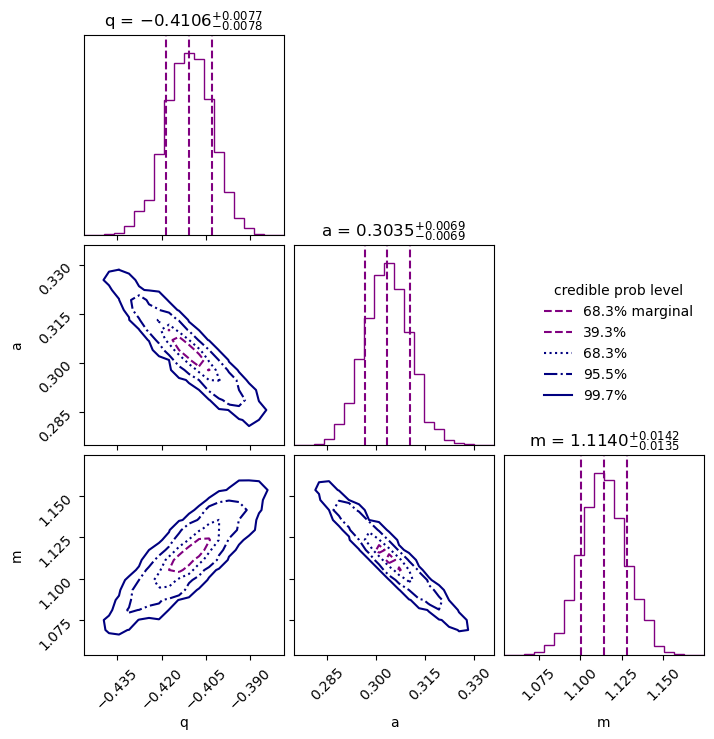

In [5]:
cornerplot(
    result_exponential,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

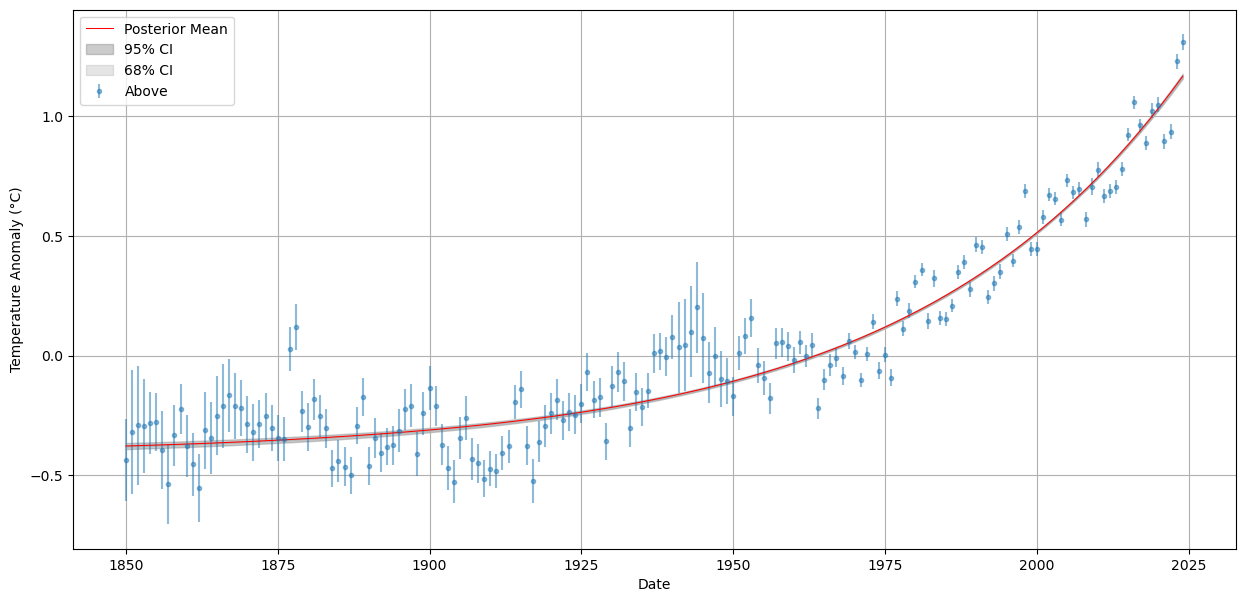

In [6]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min(), df["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_exponential["samples"]:
    q, a, m = params
    band.add(exponential_model(year_range, q, a, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [ ]:
# gaussian process regression


def gp_model(x, amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


def gp_prior(cube):
    params = cube.copy()

    lo_0 = 0.0
    hi_0 = 5.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = 0.0
    hi_1 = 100.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params



def log_gp_likelihood(params):
    amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    gp = gp_model(date, amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["amplitude", "length_scale"]


In [9]:
sampler_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_gp = sampler_gp.run()
print(result_gp)


[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=2e+01  21.8108..21.8109]*| it/evals=5160/6933 eff=78.9836% N=400  0        0 
[ultranest] Likelihood function evaluations: 6976
[ultranest]   logZ = 13.44 +- 0.0984
[ultranest] Effective samples strategy satisfied (ESS = 1569.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.10, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.01 total:0.10 required:<0.50
[ultranest] done iterating.
{'niter': 5592, 'logz': np.float64(13.44220466010588), 'logzerr': np.float64(0.1831092055400388), 'logz_bs': np.float64(13.438268739637577), 'logz_single': np.float64(13.44220466010588), 'logzerr_tail': np.float64(0.00994465266656519), 'logzerr_bs': np.float64(0.18283895929709715), 'ess': np.float64(1569.4734150217907), 'H': np.float64(7.421693219275497), 'Herr': np.float64(0.09162379053868269), 'posterior': {'mean': [0.3339296527815465,

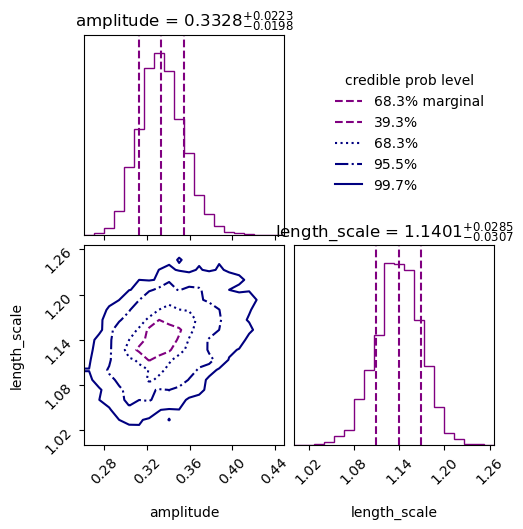

1.3813447258642144 3.1473679116712403


In [ ]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()
#print(np.exp(result_gp["samples"][0][0]), np.exp(result_gp["samples"][0][1]))

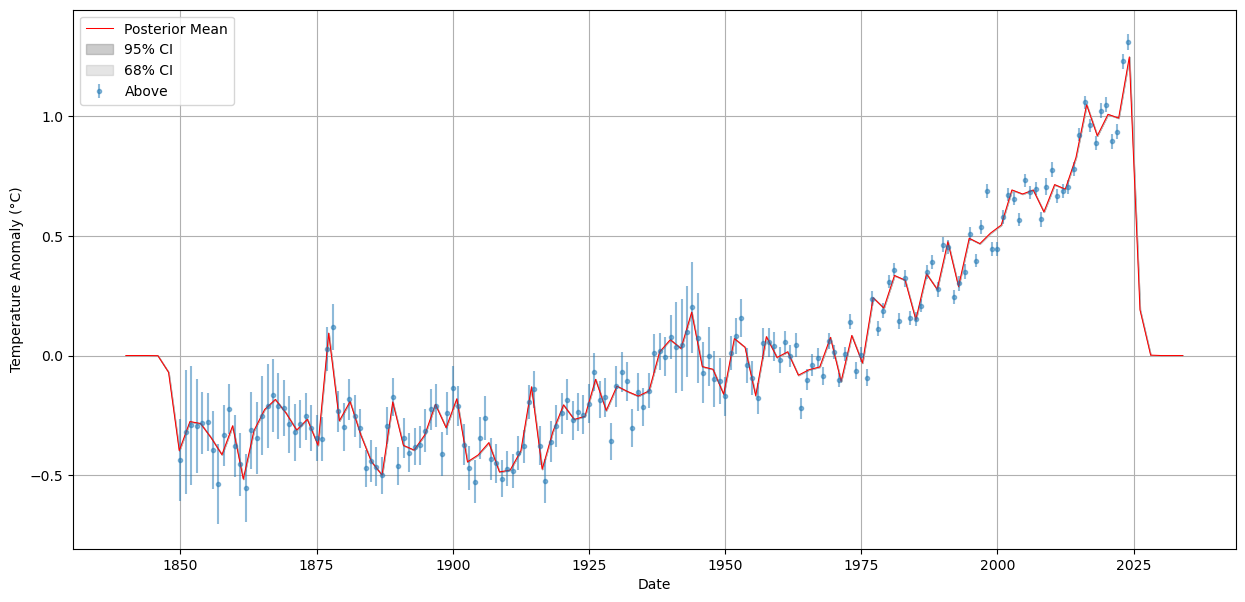

In [ ]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-10, df["year"].max()+10, 100)
band = PredictionBand(year_range)

gp_m = gp_model(date, amplitude=result_gp["samples"][0][0], length_scale=result_gp["samples"][0][1], yerr=yerr_above.to_numpy())

for params in result_gp["samples"]:
    amp, length = params
    band.add(gp_m.predict(temp_anomaly, year_range.astype(float), return_cov=False))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [30]:
def linear_trend(x, intercept, slope):
    t = (np.asarray(x) - 1950.0) / 50.0
    return intercept + slope * t


def gp_model(amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


def gp_prior(cube):
    params = np.empty_like(cube)

    # Trend parameters in data units.
    params[0] = -2.0 + cube[0] * 4.0
    params[1] = -3.0 + cube[1] * 6.0

    # Positive GP hyperparameters sampled in log space.
    params[2] = np.exp(np.log(1e-3) + cube[2] * (np.log(10.0) - np.log(1e-3)))
    params[3] = np.exp(np.log(1e-5) + cube[3] * (np.log(200.0) - np.log(1e-5)))

    return params



def log_gp_likelihood(params):
    intercept, slope, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = linear_trend(date, intercept, slope)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["trend_intercept", "trend_slope", "amplitude", "length_scale"]

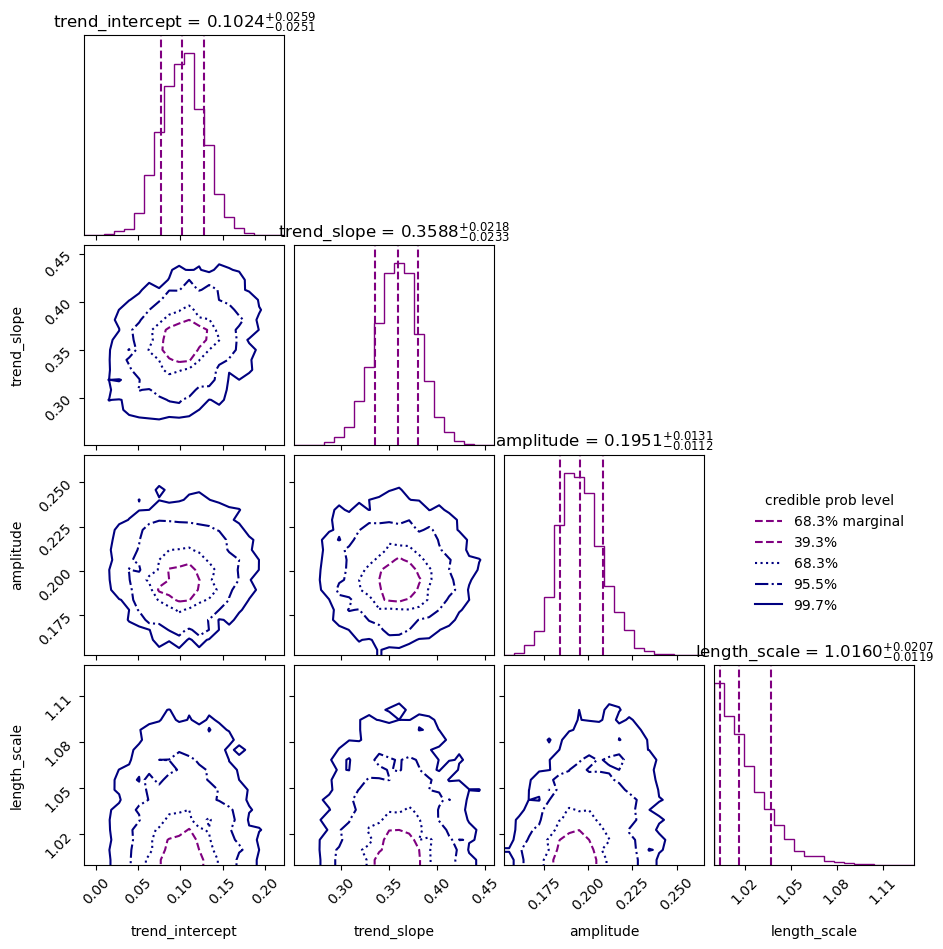

In [20]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

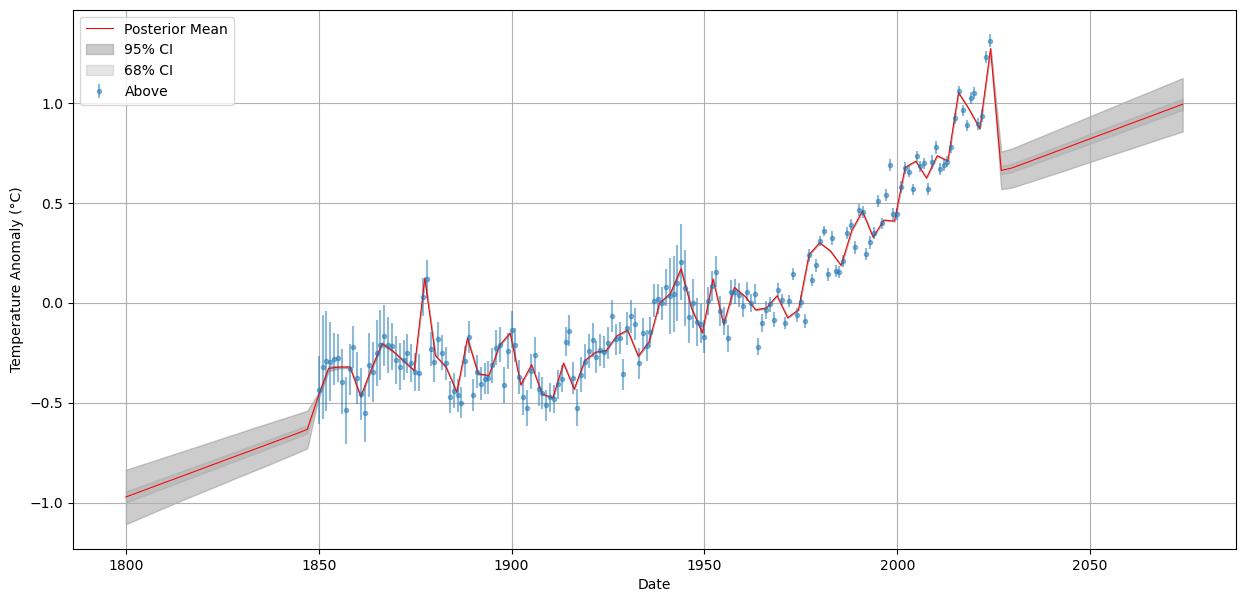

In [ ]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 100)
band = PredictionBand(year_range)

yerr = yerr_above.to_numpy()

for params in result_gp["samples"]:
    intercept, slope, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = linear_trend(date, intercept, slope)
    trend_pred = linear_trend(year_range, intercept, slope)
    gp_mean = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_cov=False, return_var=False)
    band.add(gp_mean + trend_pred)

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()


In [27]:
def exponential_trend(x, q, a, m):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + a * np.exp(m * t)


def gp_model(amplitude, length_scale, yerr):
    kernel = amplitude**2 * george.kernels.ExpSquaredKernel(length_scale**2, axes=0)
    gp = george.GP(kernel)
    gp.compute(date.astype(float), yerr)
    return gp


def gp_prior(cube):
    params = np.empty_like(cube)

    # Exponential trend parameters in data units.
    params[0] = -2.0 + cube[0] * 4.0
    params[1] = -2.0 + cube[1] * 4.0
    params[2] = -4.0 + cube[2] * 8.0

    # Positive GP hyperparameters sampled in log space.
    params[3] = np.exp(np.log(1e-3) + cube[3] * (np.log(10.0) - np.log(1e-3)))
    params[4] = np.exp(np.log(1e-5) + cube[4] * (np.log(200.0) - np.log(1e-5)))

    return params



def log_gp_likelihood(params):
    q, a, m, amp, length = params

    if amp <= 0 or length <= 0:
        return -1e300

    trend = exponential_trend(date, q, a, m)
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr_above.to_numpy())
    log_likelihood_value = gp.log_likelihood(temp_anomaly - trend, quiet=True)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_gp = ["trend_q", "trend_a", "trend_m", "amplitude", "length_scale"]

sampler_gp = ultranest.ReactiveNestedSampler(parameters_gp, log_gp_likelihood, gp_prior)
result_gp = sampler_gp.run()
print(result_gp)


[ultranest] Sampling 400 live points from prior ...


/home/steve/projects/lab-dati-02/.conda/lib/python3.11/site-packages/ultranest/integrator.py:1903: UserWarning: Sampling from region seems inefficient (0/40 accepted in iteration 2500). To improve efficiency, modify the transformation so that the current live points are ellipsoidal, or use a stepsampler, or set frac_remain to a lower number (e.g., 0.5) to terminate earlier.
  u, v, logl, nc, quality = self._refill_samples(Lmin, ndraw, nit)


[ultranest] Explored until L=1e+02  5 [140.1994..140.1996]*| it/evals=10790/558082 eff=1.9348% N=400 
[ultranest] Likelihood function evaluations: 558101
[ultranest]   logZ = 117.9 +- 0.1492
[ultranest] Effective samples strategy satisfied (ESS = 2449.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.
{'niter': 11200, 'logz': np.float64(117.88183514720643), 'logzerr': np.float64(0.26896333775034575), 'logz_bs': np.float64(117.86952230626622), 'logz_single': np.float64(117.88183514720643), 'logzerr_tail': np.float64(0.00994602854200366), 'logzerr_bs': np.float64(0.26877937712936273), 'ess': np.float64(2449.7223569587), 'H': np.float64(20.004668170326426), 'Herr': np.float64(0.13073628078442462), 'posterior': {'mean': [-0.38384237878186434

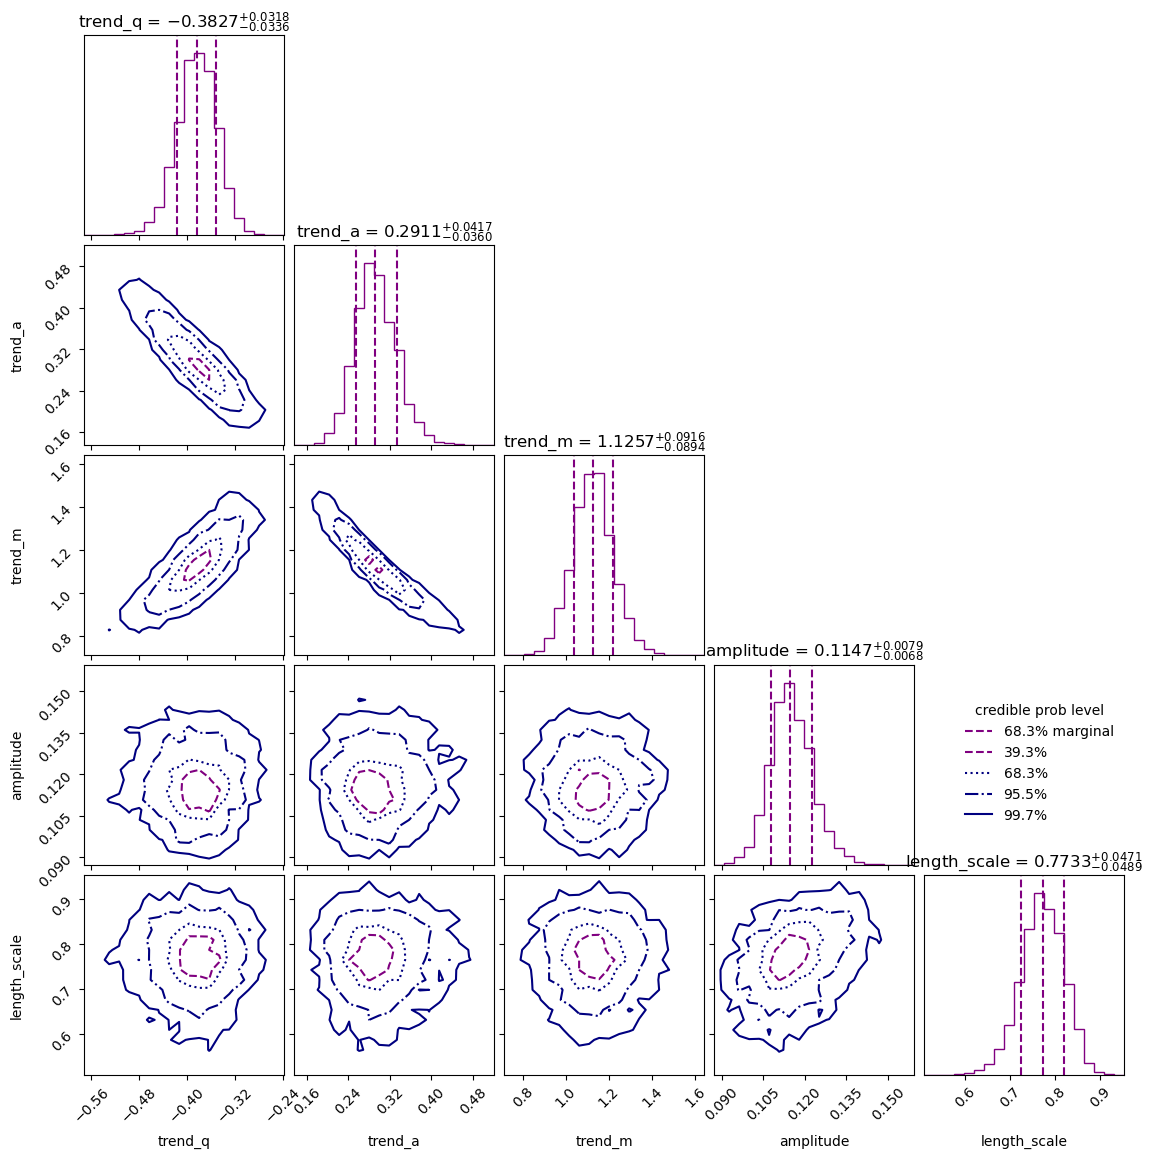

In [28]:
cornerplot(
    result_gp,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

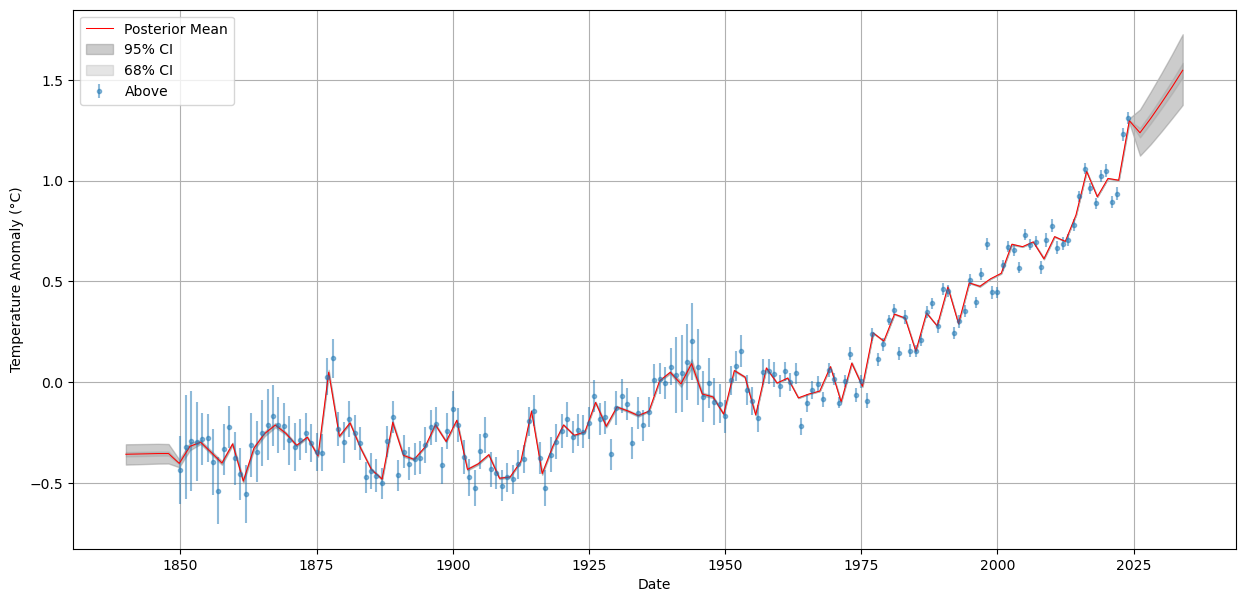

In [29]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min() - 10, df["year"].max() + 10, 100)
band = PredictionBand(year_range)

yerr = yerr_above.to_numpy()

for params in result_gp["samples"]:
    q, a, m, amp, length = params
    gp = gp_model(amplitude=amp, length_scale=length, yerr=yerr)
    trend_obs = exponential_trend(date, q, a, m)
    trend_pred = exponential_trend(year_range, q, a, m)
    gp_mean = gp.predict(temp_anomaly - trend_obs, year_range.astype(float), return_cov=False, return_var=False)
    band.add(gp_mean + trend_pred)

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()
